In [ ]:
# DATASET IMPORT
import pandas as pd
import numpy as np
df = pd.read_csv("/content/openfoodfacts_nutrition_grade_clean.csv")
TARGET = 'nutrition_grade_fr'
features = [column for column in df.columns if column != TARGET]

In [ ]:
# Dataset Overview
print("DATASET OVERVIEW")
print("-" * 50)
print(f"Number of records: {len(df):,}")
print(f"Number of features: {len(features)}")
print(f"Target column: {'nutrition_grade_fr'}")
print(f"Target class count: {df['nutrition_grade_fr'].nunique()}")
print(f"Missing values: {int(df.isna().sum().sum())}")
print(f"Duplicate records: {int(df.duplicated().sum())}")
print()

DATASET OVERVIEW
--------------------------------------------------
Number of records: 14,070
Number of features: 20
Target column: nutrition_grade_fr
Target class count: 5
Missing values: 0
Duplicate records: 0



In [ ]:
# Target Distibution
target_distribution = pd.DataFrame(
        {
            "count": df[TARGET].value_counts().sort_index(),
            "percentage": (df[TARGET].value_counts(normalize=True).sort_index() * 100).round(2),
        }
    )
print("TARGET DISTRIBUTION")
print("-" * 50)
print(target_distribution)
print()

TARGET DISTRIBUTION
--------------------------------------------------
                    count  percentage
nutrition_grade_fr                   
a                    3188       22.66
b                    3337       23.72
c                    3142       22.33
d                    3297       23.43
e                    1106        7.86



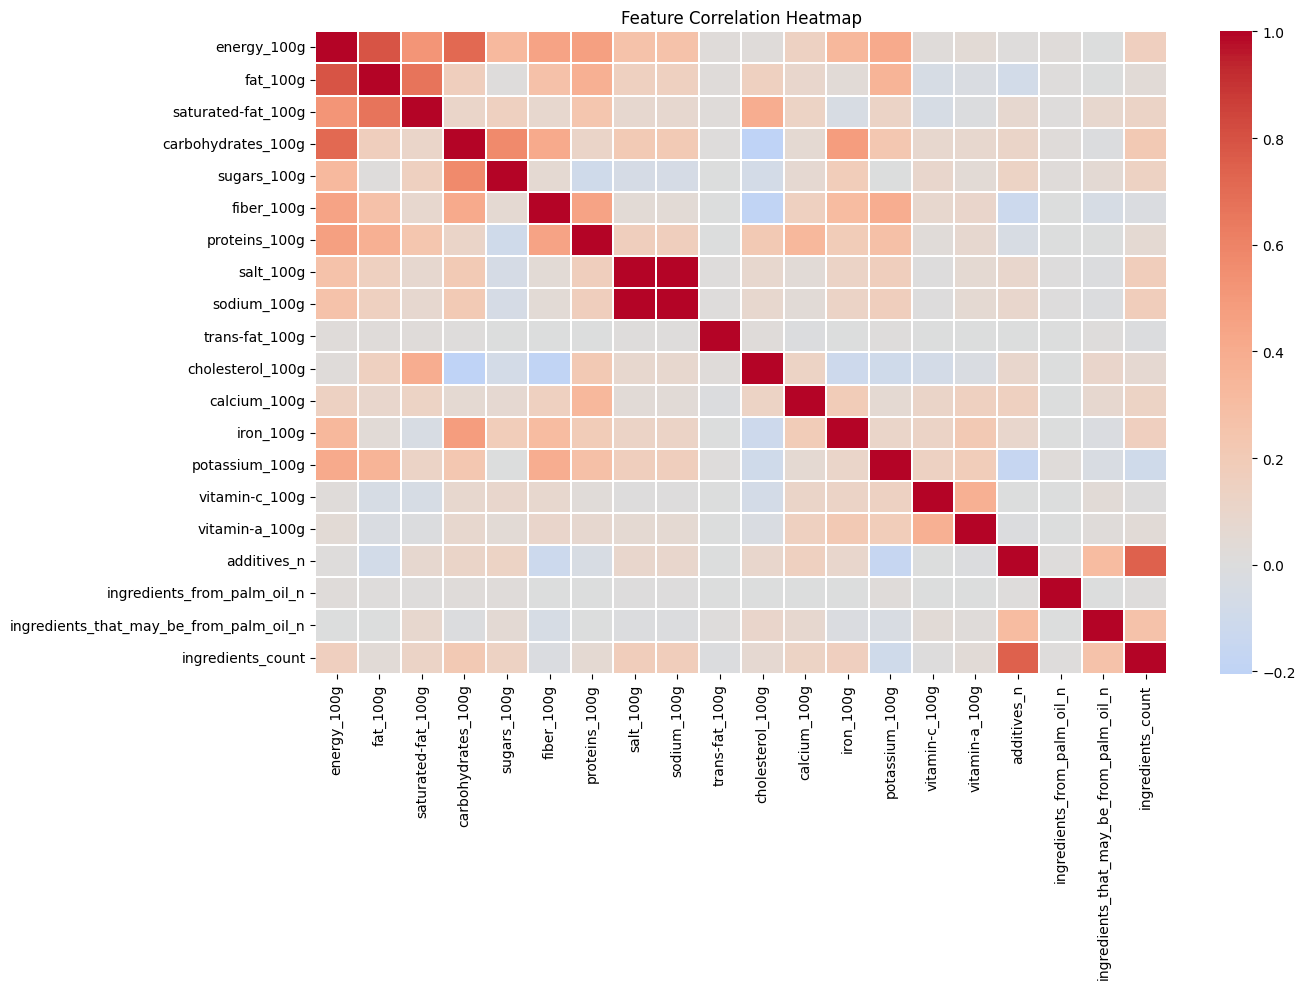

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Calculate correlation using the dataframe columns listed in features
corr_matrix = df[features].corr(method='pearson')

# Correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    annot=False,
    linewidths=0.3
)

plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

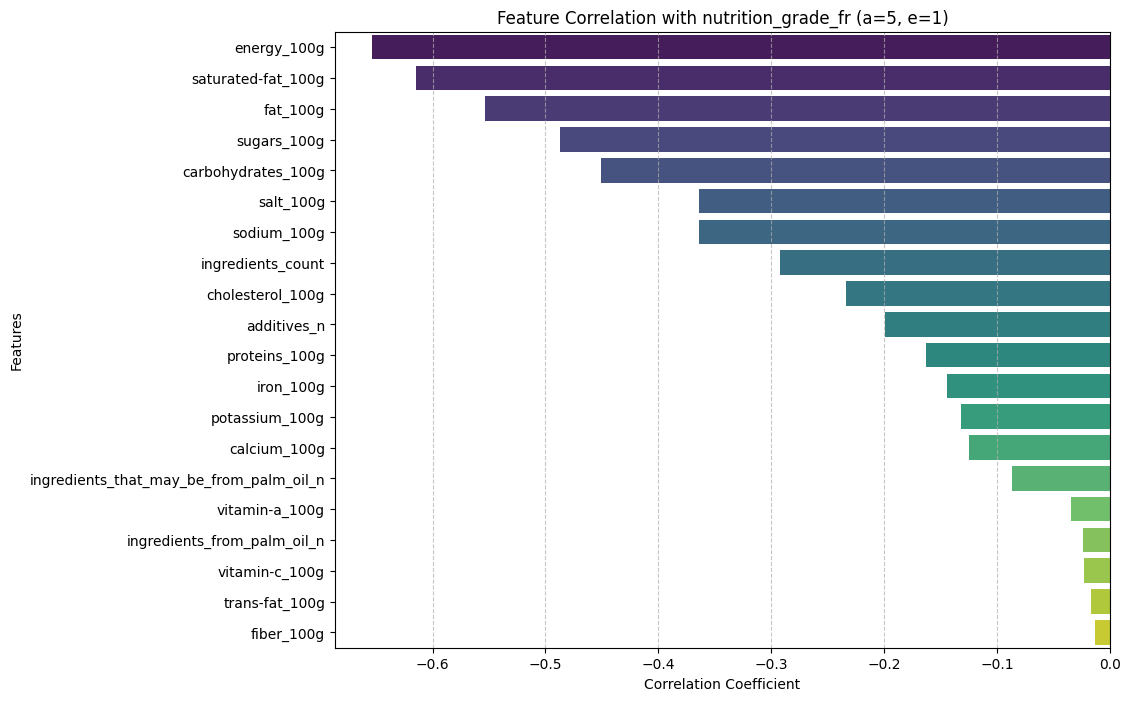

In [ ]:
# Map the target grades to numerical values (a=5, e=1)
grade_map = {'a': 5, 'b': 4, 'c': 3, 'd': 2, 'e': 1}
df_numeric_target = df.copy()
df_numeric_target[TARGET + '_num'] = df[TARGET].map(grade_map)

# Calculate correlation of features with the numeric target
target_corr = df_numeric_target[features + [TARGET + '_num']].corr()[TARGET + '_num'].drop(TARGET + '_num').sort_values()

plt.figure(figsize=(10, 8))
sns.barplot(x=target_corr.values, y=target_corr.index, hue=target_corr.index, palette='viridis', legend=False)
plt.title(f'Feature Correlation with {TARGET} (a=5, e=1)')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Ordinal Encoding
grade_mapping = {'a': 4, 'b': 3, 'c': 2, 'd': 1, 'e': 0}
df[TARGET] = df[TARGET].map(grade_mapping)

print("Dataset after Ordinal Encoding:")
display(df.head())

Dataset after Ordinal Encoding:


,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,trans-fat_100g,...,calcium_100g,iron_100g,potassium_100g,vitamin-c_100g,vitamin-a_100g,additives_n,ingredients_from_palm_oil_n,ingredients_that_may_be_from_palm_oil_n,ingredients_count,nutrition_grade_fr
0,1090.0,10.70,2.00,38.70,24.700,2.000,3.33,0.64700,0.255,0.667,...,0.0133,0.000480,0.000,0.001600,0.000000,5.0,0.0,0.0,19,2
1,478.0,6.79,2.86,7.86,0.714,0.357,5.36,0.49900,0.196,0.000,...,0.0286,0.000643,0.000,0.000429,0.000011,3.0,0.0,0.0,7,3
2,2243.0,32.14,3.57,57.14,0.000,3.600,7.14,0.95250,0.375,0.000,...,0.0000,0.001290,1.536,0.021400,0.000000,0.0,0.0,0.0,3,2
3,192.0,0.00,0.00,11.67,10.420,0.000,0.00,0.03810,0.015,0.000,...,0.0000,0.000150,0.079,0.000000,0.000000,0.0,0.0,0.0,3,3
4,226.0,0.00,0.00,13.33,13.330,0.000,0.00,0.01016,0.004,0.000,...,0.0000,0.000000,0.015,0.000500,0.000000,0.0,0.0,0.0,3,3


**5 ML MODELS**

In [ ]:
from sklearn.model_selection import train_test_split

X = df[features]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (11256, 20)
Test set shape: (2814, 20)


**SCALED FOR LOGISTIC REGRESSION AND KNN**

In [ ]:
# Scaler for Logistic Regression and KNN (z-score norm.)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**LOGISTIC REGRESSION**

In [ ]:
# Logistic Regression model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

model = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=42
)

# Model train
model.fit(X_train_scaled, y_train)

# Prediction
y_pred = model.predict(X_test_scaled)

In [ ]:
# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")
print("Logistic Regression Results")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Logistic Regression Results
Accuracy: 0.7590618336886994
Precision: 0.7573805442435688
Recall: 0.7762932201909114
F1-score: 0.7642458045861517

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.89      0.79       221
           1       0.85      0.75      0.80       659
           2       0.71      0.75      0.73       628
           3       0.70      0.71      0.71       668
           4       0.81      0.79      0.80       638

    accuracy                           0.76      2814
   macro avg       0.76      0.78      0.76      2814
weighted avg       0.76      0.76      0.76      2814



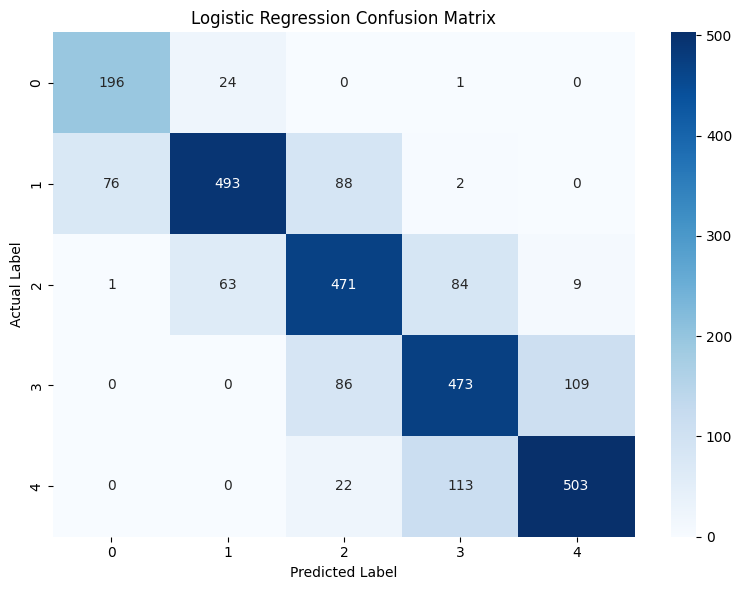

In [ ]:
# Confusion Matrix
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

**KNN**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("Best CV F1-score:")
print(grid_search.best_score_)

best_knn = grid_search.best_estimator_

y_pred = best_knn.predict(X_test_scaled)

Best Parameters:
{'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
Best CV F1-score:
0.8610504773948673


In [ ]:
# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("\nKNN with Cross Validation Results")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


KNN with Cross Validation Results
Accuracy: 0.8546552949538024
Precision: 0.8608363204808833
Recall: 0.8514040380803095
F1-score: 0.8556450430533022

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.83      0.86       221
           1       0.86      0.86      0.86       659
           2       0.83      0.81      0.82       628
           3       0.81      0.87      0.84       668
           4       0.91      0.89      0.90       638

    accuracy                           0.85      2814
   macro avg       0.86      0.85      0.86      2814
weighted avg       0.86      0.85      0.85      2814



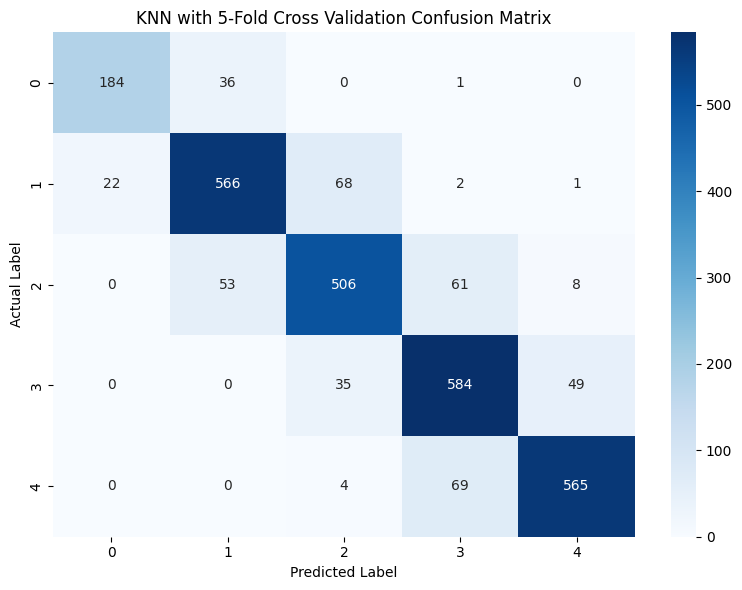

In [ ]:
# Confusion Matrix
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("KNN with 5-Fold Cross Validation Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

**DECISION TREE**

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
# Decision Tree model
dt_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=12,
    min_samples_leaf=5,
    min_samples_split=2,
    class_weight="balanced",
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)

In [ ]:
# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("Decision Tree Results")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Decision Tree Results
Accuracy: 0.8834399431414357
Precision: 0.8770079281415704
Recall: 0.8862901662580251
F1-score: 0.8812328843443874

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.87       221
           1       0.90      0.86      0.88       659
           2       0.86      0.86      0.86       628
           3       0.87      0.88      0.87       668
           4       0.93      0.92      0.93       638

    accuracy                           0.88      2814
   macro avg       0.88      0.89      0.88      2814
weighted avg       0.88      0.88      0.88      2814



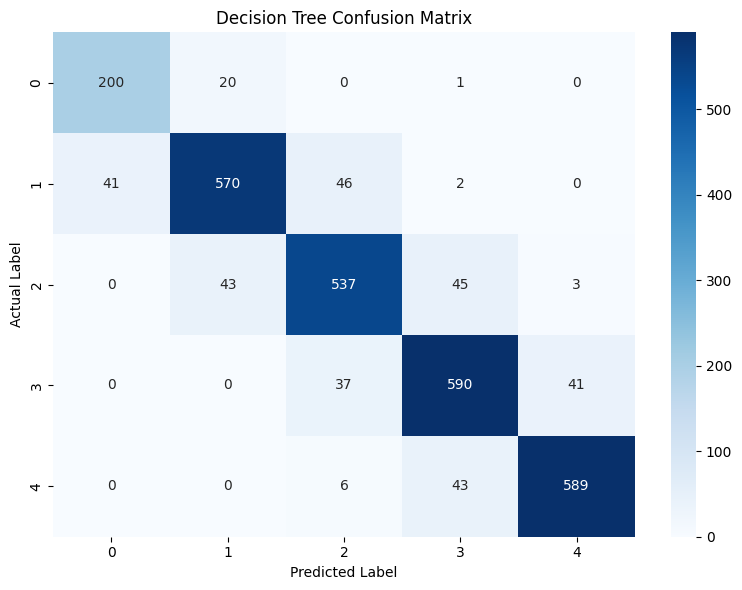

In [ ]:
# Confusion Matrix
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

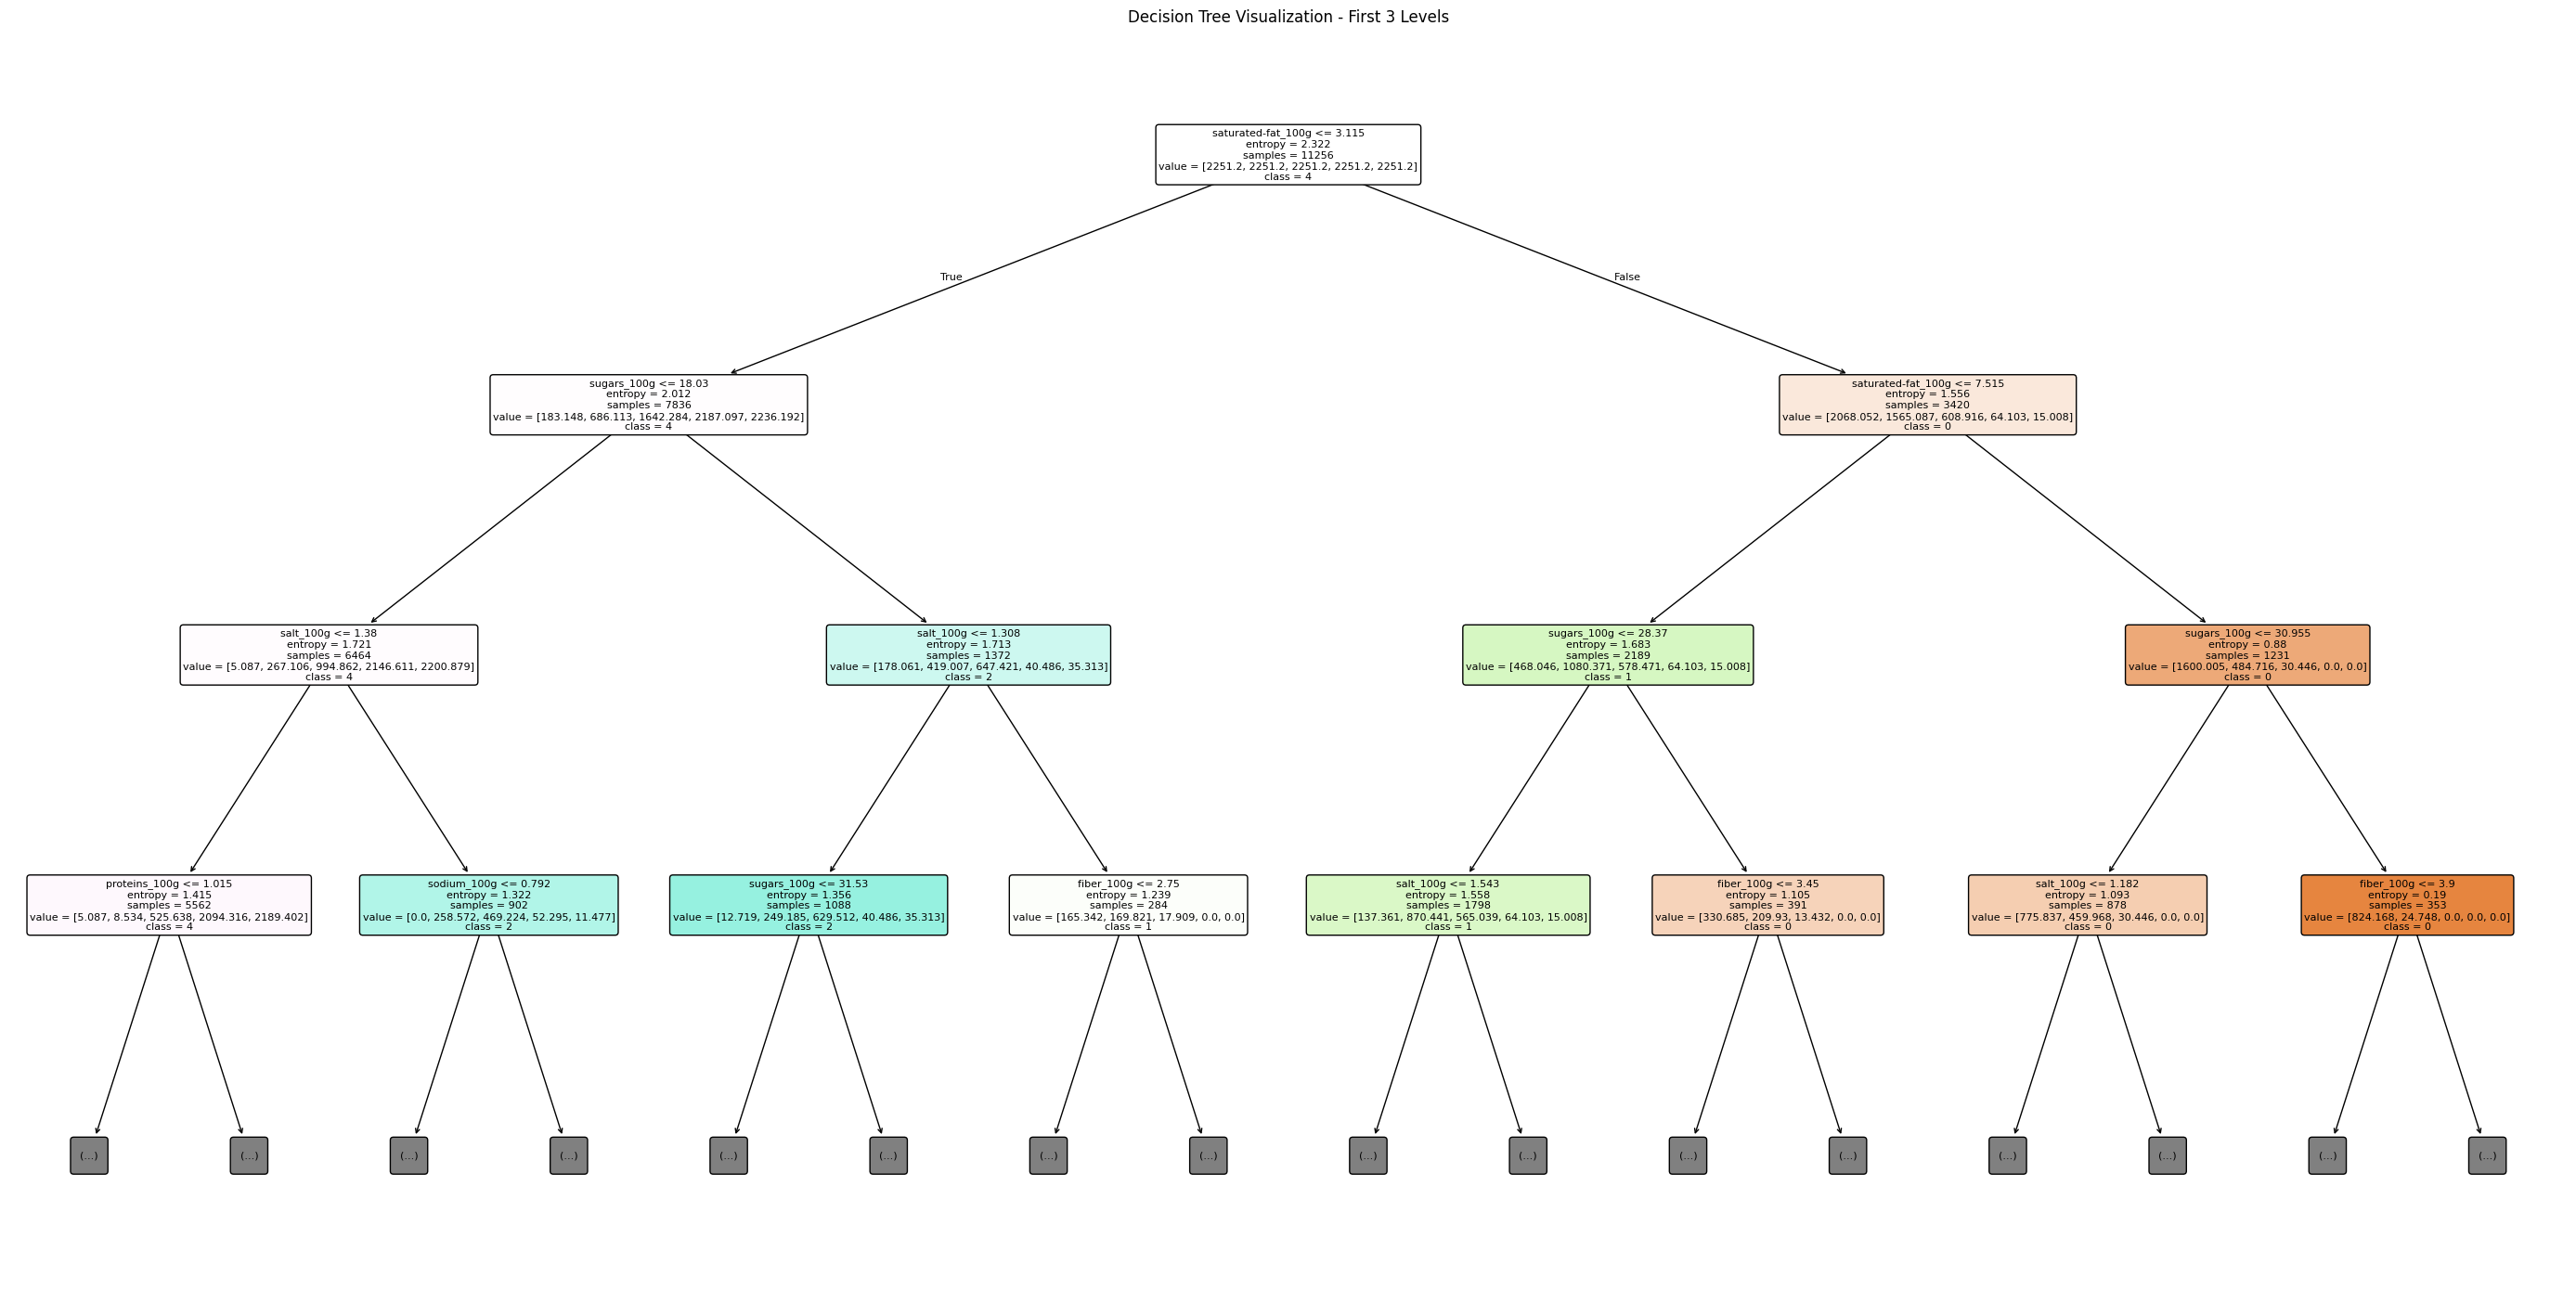

In [ ]:
# Decision Tree Visualization
# turn class to string for
labels = [str(label) for label in sorted(y.unique())]
plt.figure(figsize=(28, 14))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=labels,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)

plt.title("Decision Tree Visualization - First 3 Levels")
plt.tight_layout()
plt.show()

**RANDOM FOREST**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    criterion="entropy",
    max_depth=12, # Prevent overfitting
    min_samples_split=5,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

In [ ]:
# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("Random Forest Results")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Random Forest Results
Accuracy: 0.8841506751954513
Precision: 0.8843441273958496
Recall: 0.8860006567281404
F1-score: 0.8849194071368316

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.90      0.89       221
           1       0.91      0.88      0.90       659
           2       0.83      0.89      0.86       628
           3       0.87      0.85      0.86       668
           4       0.93      0.91      0.92       638

    accuracy                           0.88      2814
   macro avg       0.88      0.89      0.88      2814
weighted avg       0.89      0.88      0.88      2814



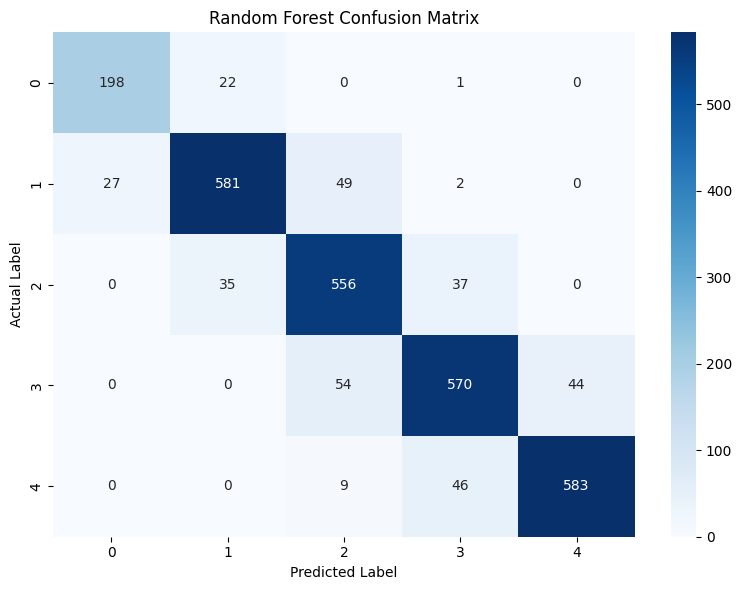

In [ ]:
# Confusion Matrix
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

**XGBOOST**

In [ ]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

y_train_xgb = y_train
y_test_xgb = y_test

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train_xgb
)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train_xgb,
    sample_weight=sample_weights
)

# Direct prediction in 0-4 range
y_pred = xgb_model.predict(X_test)

In [ ]:
# Metrics for XGBoost
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("XGBoost Results")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

XGBoost Results
Accuracy: 0.9324804548685146
Precision: 0.9330415805904971
Recall: 0.9307956633044585
F1-score: 0.9318237927145738

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       221
           1       0.94      0.92      0.93       659
           2       0.89      0.92      0.91       628
           3       0.93      0.93      0.93       668
           4       0.97      0.97      0.97       638

    accuracy                           0.93      2814
   macro avg       0.93      0.93      0.93      2814
weighted avg       0.93      0.93      0.93      2814



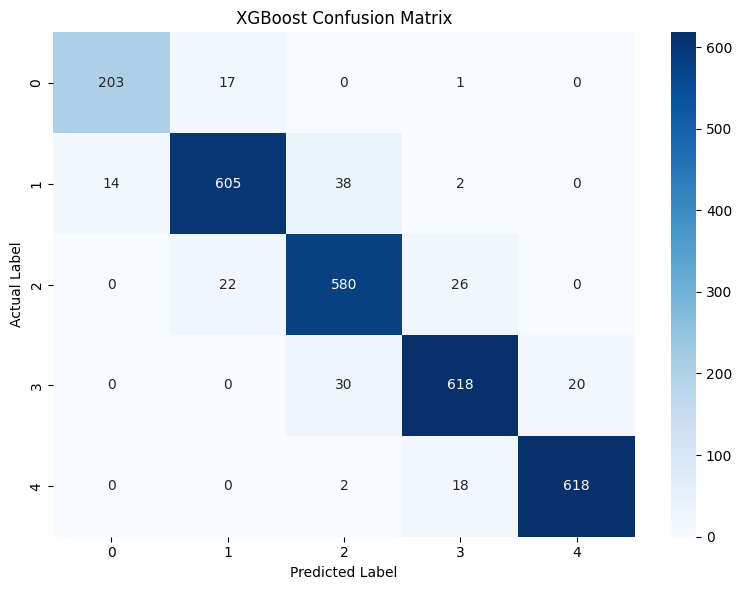

In [ ]:
# Confusion Matrix for XGBoost
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

**3 DL MODELS**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight

**MLP**

In [ ]:
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

y_train_final_cat = to_categorical(y_train_final, num_classes=5)
y_val_cat = to_categorical(y_val, num_classes=5)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calculate class weights using the standardized 0-4 labels
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights_array))

In [ ]:
mlp_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(128, activation="relu"),
    Dropout(0.30),
    Dense(64, activation="relu"),
    Dropout(0.20),
    Dense(32, activation="relu"),
    Dense(5, activation="softmax")
])

mlp_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# Already 0-4
y_train_cat_aligned = to_categorical(y_train, num_classes=5)

history = mlp_model.fit(
    X_train_scaled,
    y_train_cat_aligned,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    class_weight=class_weights,
    verbose=1
)

y_pred_prob = mlp_model.predict(X_test_scaled)
y_pred_labels = np.argmax(y_pred_prob, axis=1)

Epoch 1/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - accuracy: 0.5726 - loss: 0.9085 - val_accuracy: 0.7722 - val_loss: 0.5958
Epoch 2/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7372 - loss: 0.5898 - val_accuracy: 0.8179 - val_loss: 0.4436
Epoch 3/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7898 - loss: 0.4876 - val_accuracy: 0.8526 - val_loss: 0.3781
Epoch 4/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8038 - loss: 0.4515 - val_accuracy: 0.8535 - val_loss: 0.3689
Epoch 5/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8181 - loss: 0.4289 - val_accuracy: 0.8552 - val_loss: 0.3537
Epoch 6/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8315 - loss: 0.4047 - val_accuracy: 0.8712 - val_loss: 0.3219
Epoch 7/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8393 - loss: 0.3778 - val_accuracy: 0.8726 - val_loss: 0.3153
Epoch 8/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8412 - loss: 0.3681 - val_ac

In [ ]:
accuracy = accuracy_score(y_test, y_pred_labels)
precision = precision_score(y_test, y_pred_labels, average="macro")
recall = recall_score(y_test, y_pred_labels, average="macro")
f1 = f1_score(y_test, y_pred_labels, average="macro")

print("MLP Results")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_labels,
    target_names=["0", "1", "2", "3", "4"]
))

MLP Results
Accuracy: 0.9111584932480455
Precision: 0.908336341316702
Recall: 0.9166018053818826
F1-score: 0.9115231880822913

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.95      0.91       221
           1       0.94      0.91      0.92       659
           2       0.92      0.87      0.90       628
           3       0.85      0.93      0.89       668
           4       0.95      0.92      0.94       638

    accuracy                           0.91      2814
   macro avg       0.91      0.92      0.91      2814
weighted avg       0.91      0.91      0.91      2814



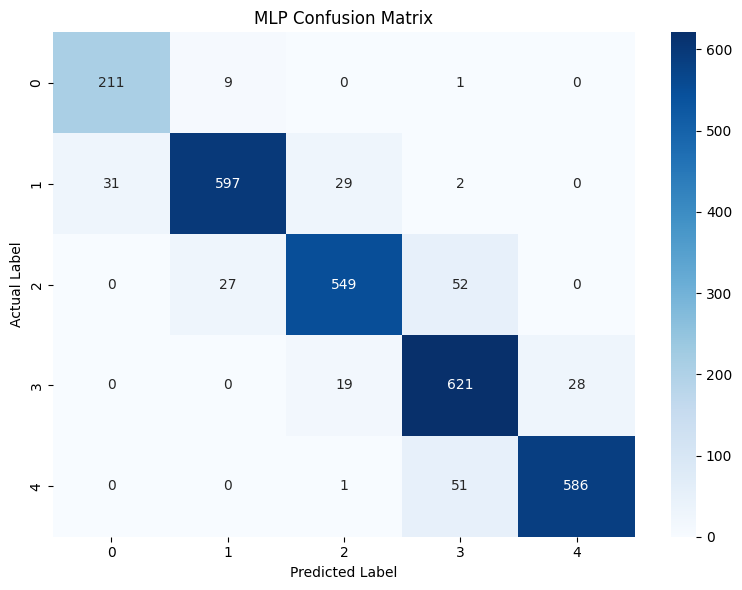

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_labels, labels=[0, 1, 2, 3, 4])

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[0, 1, 2, 3, 4],
    yticklabels=[0, 1, 2, 3, 4]
)

plt.title("MLP Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

**DNN**

In [ ]:
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
num_classes = 5
class_names = ["a", "b", "c", "d", "e"]

# Train-validation split
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# One-hot encoding
y_train_final_cat = to_categorical(y_train_final, num_classes=num_classes)
y_val_cat = to_categorical(y_val, num_classes=num_classes)

# Class weights
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_final),
    y=y_train_final
)

class_weights = dict(enumerate(class_weights_array))
dnn_model = Sequential([
    Input(shape=(X_train_final.shape[1],)),

    Dense(256, activation="relu"),
    BatchNormalization(),
    Dropout(0.35),

    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.30),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.20),

    Dense(32, activation="relu"),

    Dense(num_classes, activation="softmax")
])

# Compile
dnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Early stopping
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# Train
history = dnn_model.fit(
    X_train_final,
    y_train_final_cat,
    validation_data=(X_val, y_val_cat),
    epochs=120,
    batch_size=32,
    callbacks=[early_stopping],
    class_weight=class_weights,
    verbose=1
)

# Prediction
y_pred_prob = dnn_model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)

Epoch 1/120
282/282 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.5891 - loss: 0.8978 - val_accuracy: 0.7544 - val_loss: 0.6231
Epoch 2/120
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7179 - loss: 0.6239 - val_accuracy: 0.8042 - val_loss: 0.4708
Epoch 3/120
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7524 - loss: 0.5530 - val_accuracy: 0.8317 - val_loss: 0.4081
Epoch 4/120
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7684 - loss: 0.5132 - val_accuracy: 0.8477 - val_loss: 0.3914
Epoch 5/120
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7708 - loss: 0.4997 - val_accuracy: 0.8472 - val_loss: 0.3921
Epoch 6/120
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7842 - loss: 0.4774 - val_accuracy: 0.8628 - val_loss: 0.3541
Epoch 7/120
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7909 - loss: 0.4522 - val_accuracy: 0.8726 - val_loss: 0.3412
Epoch 8/120
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8034 - loss: 0.4322 - val_ac

In [ ]:
# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("DNN Results")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))


DNN Results
Accuracy: 0.8951670220326937
Precision: 0.8919002578342811
Recall: 0.9021568386893127
F1-score: 0.8962173558793239

Classification Report:
              precision    recall  f1-score   support

           a       0.86      0.95      0.90       221
           b       0.95      0.87      0.91       659
           c       0.87      0.90      0.88       628
           d       0.86      0.87      0.87       668
           e       0.92      0.93      0.92       638

    accuracy                           0.90      2814
   macro avg       0.89      0.90      0.90      2814
weighted avg       0.90      0.90      0.90      2814



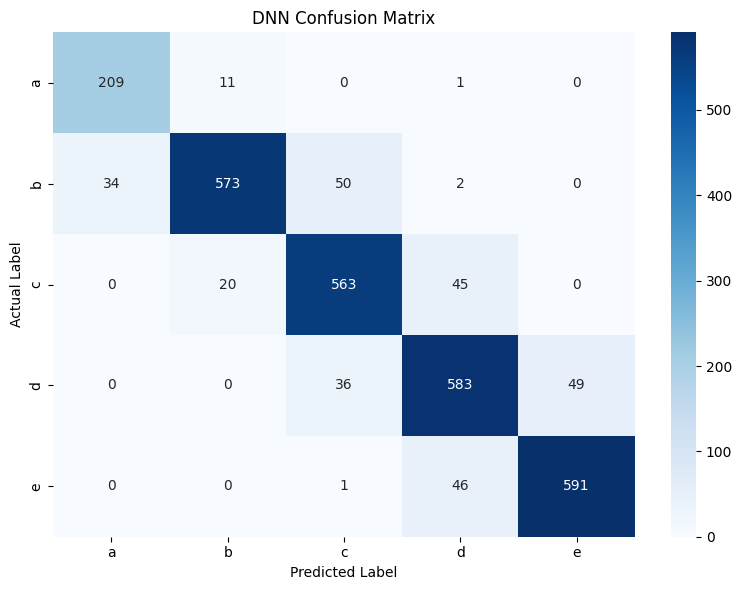

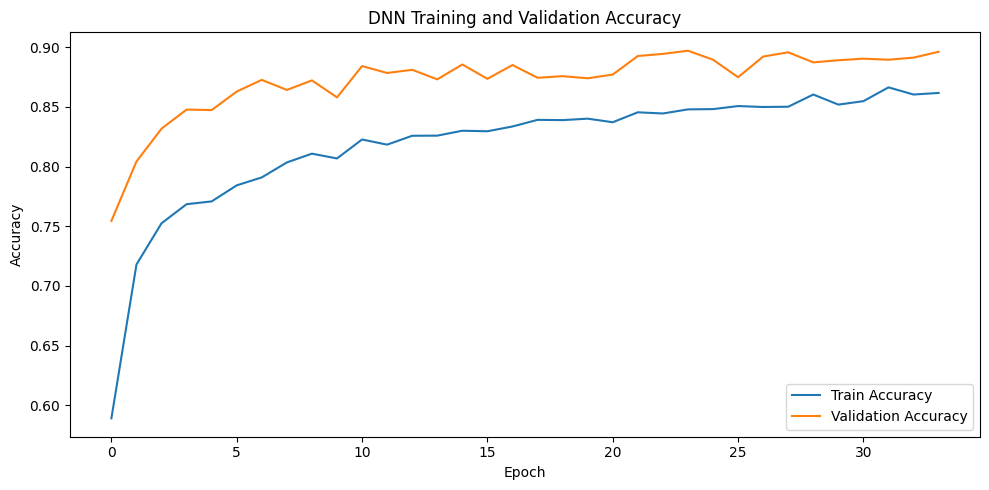

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2, 3, 4])

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("DNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

# Accuracy Plot
plt.figure(figsize=(10, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("DNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

In [ ]:
num_classes = 5
class_names = ["a", "b", "c", "d", "e"]

# 1D CNN input shape: (samples, features, channels)
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

# Train-validation split
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_cnn,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# One-hot encoding
y_train_final_cat = to_categorical(y_train_final, num_classes=num_classes)
y_val_cat = to_categorical(y_val, num_classes=num_classes)

# Class weights
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_final),
    y=y_train_final
)

class_weights = dict(enumerate(class_weights_array))

# 1D CNN Model
cnn_model = Sequential([
    Input(shape=(X_train_cnn.shape[1], 1)),

    Conv1D(filters=64, kernel_size=3, activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.25),

    Conv1D(filters=128, kernel_size=3, activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.30),

    Flatten(),

    Dense(64, activation="relu"),
    Dropout(0.30),

    Dense(num_classes, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = cnn_model.fit(
    X_train_final,
    y_train_final_cat,
    validation_data=(X_val, y_val_cat),
    epochs=120,
    batch_size=32,
    callbacks=[early_stopping],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/120
282/282 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.5555 - loss: 1.0659 - val_accuracy: 0.6123 - val_loss: 0.9256
Epoch 2/120
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6946 - loss: 0.6840 - val_accuracy: 0.7660 - val_loss: 0.5702
Epoch 3/120
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7407 - loss: 0.5949 - val_accuracy: 0.8002 - val_loss: 0.4848
Epoch 4/120
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7606 - loss: 0.5351 - val_accuracy: 0.8197 - val_loss: 0.4480
Epoch 5/120
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7834 - loss: 0.5016 - val_accuracy: 0.8393 - val_loss: 0.4087
Epoch 6/120
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7871 - loss: 0.4744 - val_accuracy: 0.8472 - val_loss: 0.3703
Epoch 7/120
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8053 - loss: 0.4424 - val_accuracy: 0.8490 - val_loss: 0.3848
Epoch 8/120
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8094 - loss: 0.4356 - val_ac

In [ ]:
# Prediction
y_pred_prob = cnn_model.predict(X_test_cnn)
y_pred = np.argmax(y_pred_prob, axis=1)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("1D CNN Results")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))


88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
1D CNN Results
Accuracy: 0.8923240938166311
Precision: 0.892814668423364
Recall: 0.8913783973460783
F1-score: 0.8919446697846393

Classification Report:
              precision    recall  f1-score   support

           a       0.89      0.89      0.89       221
           b       0.89      0.92      0.90       659
           c       0.88      0.85      0.86       628
           d       0.86      0.89      0.87       668
           e       0.95      0.92      0.93       638

    accuracy                           0.89      2814
   macro avg       0.89      0.89      0.89      2814
weighted avg       0.89      0.89      0.89      2814



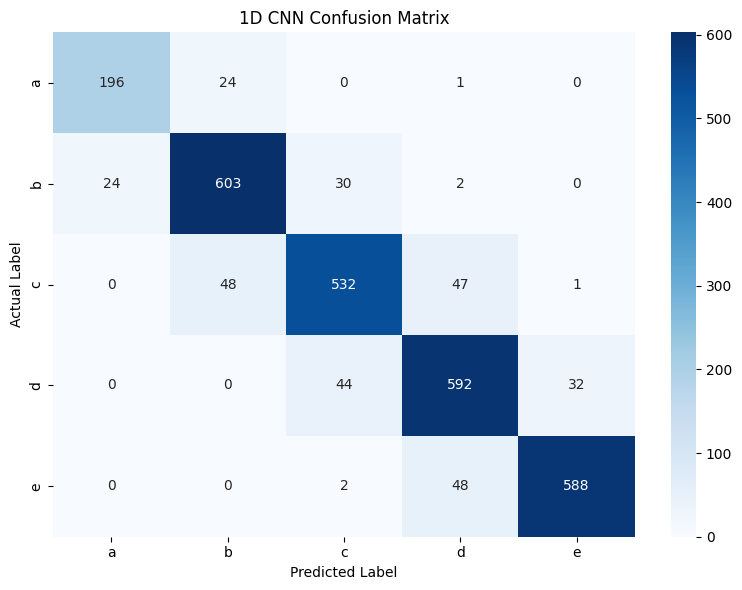

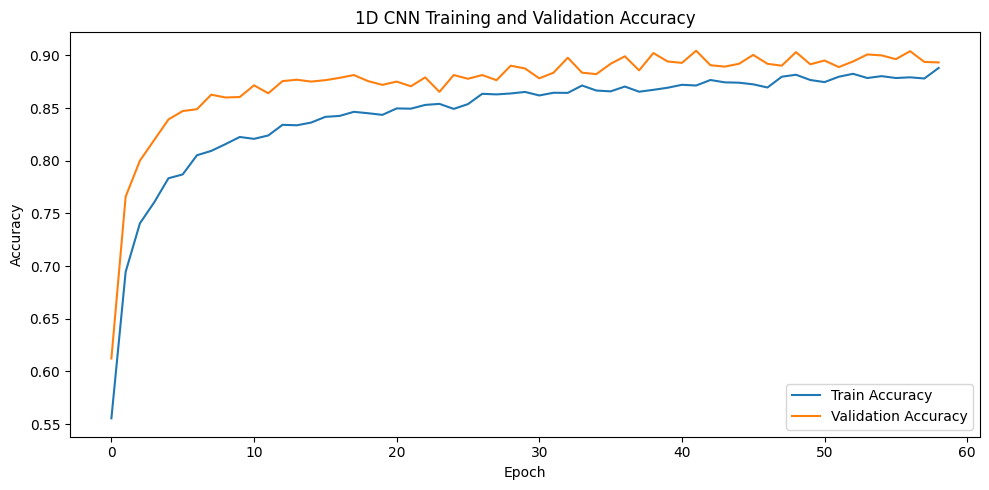

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2, 3, 4])

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("1D CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

# Accuracy Plot
plt.figure(figsize=(10, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("1D CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

**For the best accuracy model, use SMOTE for Data Balancing and show Confusion Matrix before and after. (only for real data)**

In [ ]:
from imblearn.over_sampling import SMOTE
# SMOTE sadece training data'ya uygulanır
smote = SMOTE(
    random_state=42,
    k_neighbors=5
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts().sort_index())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts().sort_index())

# XGBoost model with SMOTE
xgb_model_smote = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb_model_smote.fit(
    X_train_smote,
    y_train_smote
)

# Test set aynı kalıyor, SMOTE uygulanmıyor
y_pred_smote = xgb_model_smote.predict(X_test)

Before SMOTE:
nutrition_grade_fr
0     885
1    2638
2    2514
3    2669
4    2550
Name: count, dtype: int64

After SMOTE:
nutrition_grade_fr
0    2669
1    2669
2    2669
3    2669
4    2669
Name: count, dtype: int64


In [ ]:
print("XGBoost with SMOTE Results")
print("Accuracy:", accuracy_score(y_test, y_pred_smote))
print("Precision:", precision_score(y_test, y_pred_smote, average="macro"))
print("Recall:", recall_score(y_test, y_pred_smote, average="macro"))
print("F1-score:", f1_score(y_test, y_pred_smote, average="macro"))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_smote,
    target_names=class_names
))

XGBoost with SMOTE Results
Accuracy: 0.9314143567874911
Precision: 0.9315844385910772
Recall: 0.9298752034074929
F1-score: 0.9306276390794459

Classification Report:
              precision    recall  f1-score   support

           a       0.93      0.92      0.92       221
           b       0.94      0.92      0.93       659
           c       0.89      0.92      0.91       628
           d       0.93      0.93      0.93       668
           e       0.97      0.97      0.97       638

    accuracy                           0.93      2814
   macro avg       0.93      0.93      0.93      2814
weighted avg       0.93      0.93      0.93      2814



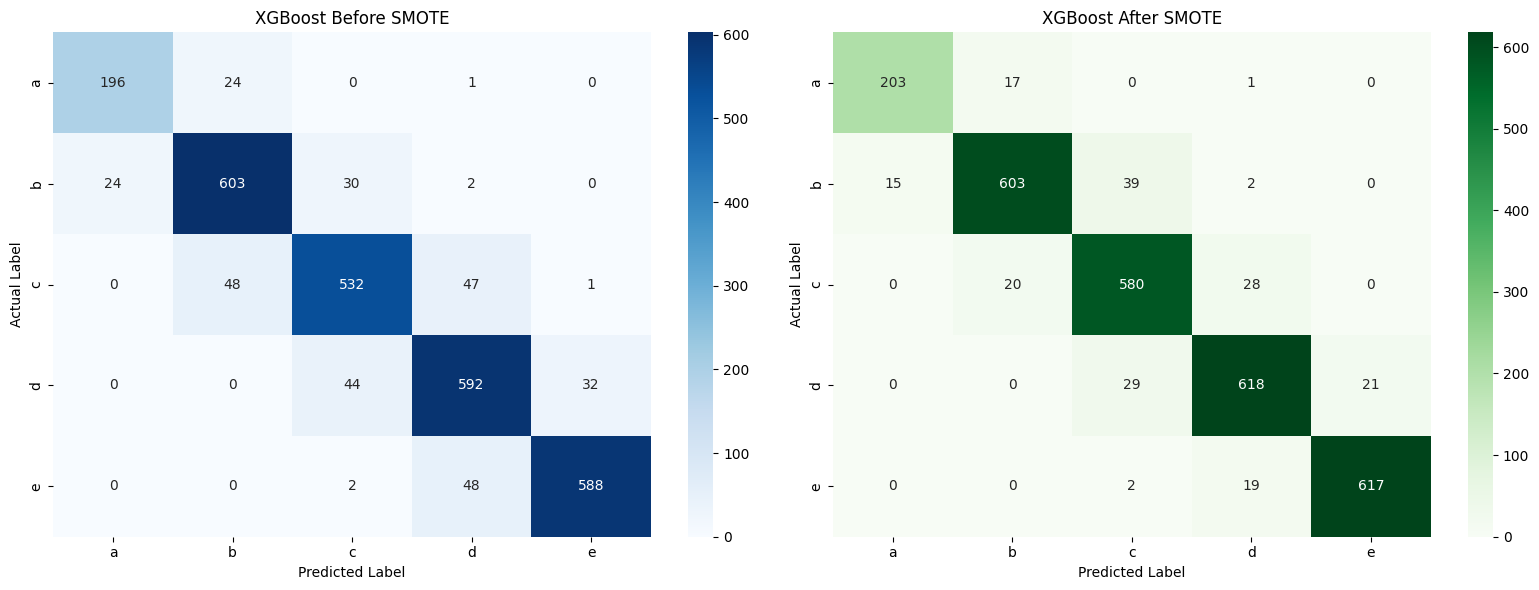

In [ ]:
cm_before = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1, 2, 3, 4]
)

cm_after = confusion_matrix(
    y_test,
    y_pred_smote,
    labels=[0, 1, 2, 3, 4]
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    cm_before,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0]
)

axes[0].set_title("XGBoost Before SMOTE")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("Actual Label")

sns.heatmap(
    cm_after,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[1]
)

axes[1].set_title("XGBoost After SMOTE")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("Actual Label")

plt.tight_layout()
plt.show()

**Feature Selection/Reduction – Comparison (for selected features)**

Selected Top 10 Features: ['saturated-fat_100g', 'energy_100g', 'sugars_100g', 'proteins_100g', 'fiber_100g', 'salt_100g', 'sodium_100g', 'fat_100g', 'carbohydrates_100g', 'ingredients_from_palm_oil_n']


/tmp/ipykernel_903/617805116.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df.head(10), palette='magma')


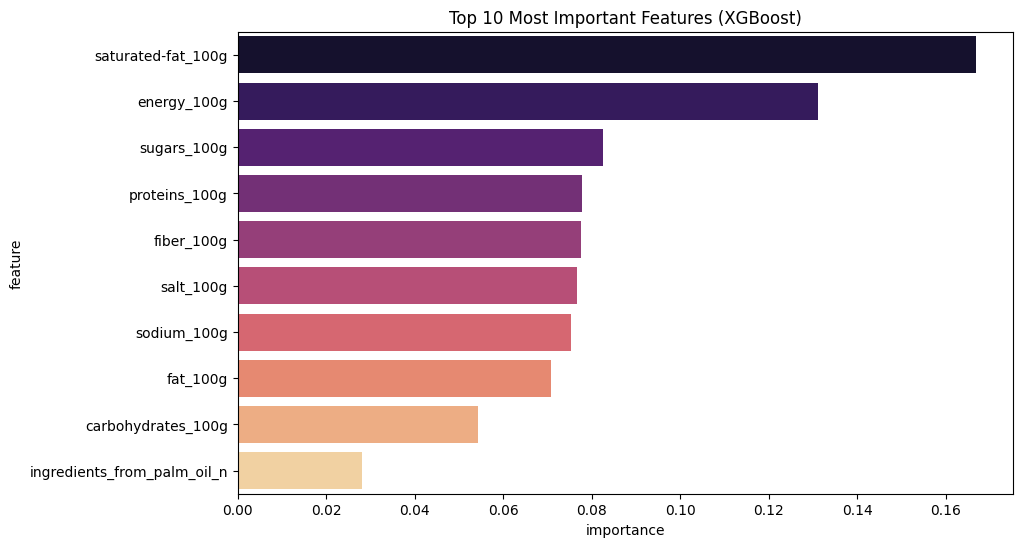

In [47]:
Get Feature Importances from the existing xgb_model
importances = xgb_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# 2. Select top 10 features
selected_features = feature_importance_df.head(10)['feature'].tolist()
print(f"Selected Top 10 Features: {selected_features}")

# Visualize the top 10
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(10), palette='magma')
plt.title('Top 10 Most Important Features (XGBoost)')
plt.show()

XGBoost (Top 10 Features) Results
Accuracy: 0.9349680170575693

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.92      0.94       221
           1       0.94      0.93      0.93       659
           2       0.90      0.92      0.91       628
           3       0.93      0.93      0.93       668
           4       0.97      0.97      0.97       638

    accuracy                           0.93      2814
   macro avg       0.94      0.93      0.94      2814
weighted avg       0.94      0.93      0.94      2814



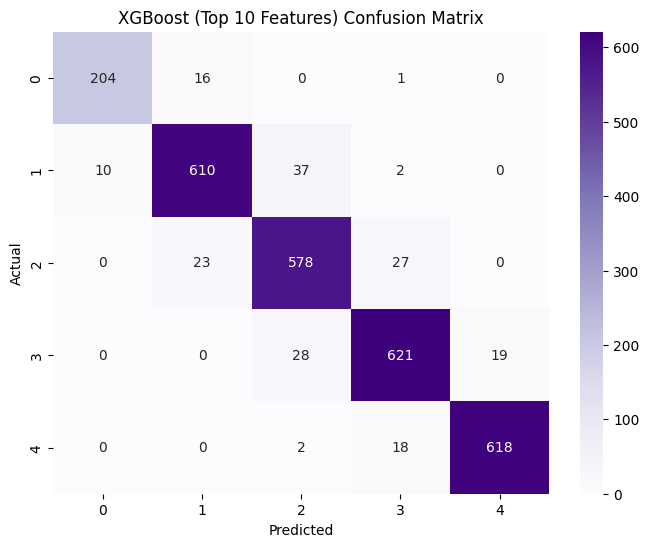

In [46]:
Prepare data with selected features
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]


sample_weights_selected = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

# 5. Train new XGBoost model with only top 10 features
xgb_model_top10 = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb_model_top10.fit(
    X_train_selected,
    y_train,
    sample_weight=sample_weights_selected
)


y_pred_top10 = xgb_model_top10.predict(X_test_selected)

print("XGBoost (Top 10 Features) Results")
print("Accuracy:", accuracy_score(y_test, y_pred_top10))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_top10))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_top10), annot=True, fmt='d', cmap='Purples')
plt.title('XGBoost (Top 10 Features) Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Modelleri Kaydetme (Model Serialization)

Bu bölümde eğittiğimiz modelleri daha sonra kullanmak üzere `.joblib` ve `.keras` formatlarında kaydedeceğiz.

In [ ]:
import joblib
import os

# Klasik Modelleri Kaydetme (Scikit-learn ve XGBoost)
joblib.dump(xgb_model, 'xgb_model_full.joblib')
joblib.dump(xgb_model_top10, 'xgb_model_top10.joblib')
joblib.dump(rf_model, 'random_forest_model.joblib')
joblib.dump(scaler, 'scaler.joblib') # Ölçekleyiciyi kaydetmek çok önemlidir!

# Derin Öğrenme Modellerini Kaydetme (Keras/TensorFlow)
mlp_model.save('mlp_model.keras')
dnn_model.save('dnn_model.keras')
cnn_model.save('cnn_model.keras')

print("Tüm modeller başarıyla kaydedildi.")

Kaydettiğiniz modelleri sol taraftaki **Dosyalar (Files)** ikonuna tıklayarak görebilir ve sağ tıklayıp 'İndir' diyerek bilgisayarınıza alabilirsiniz. Kod ile indirmek isterseniz şu hücreyi kullanabilirsiniz:

In [ ]:
from google.colab import files

# Örnek: En iyi sonucu veren XGBoost modelini indir
# files.download('xgb_model_top10.joblib')
# files.download('scaler.joblib')

### Tüm Modelleri Kaydetme
Aşağıdaki hücre, notebook boyunca eğittiğimiz tüm başarılı modelleri kalıcı hale getirir.

In [48]:
import joblib

# 1. Klasik Modelleri ve Scaler'ı Kaydet (.joblib)
try:
    joblib.dump(xgb_model, 'xgb_model_full.joblib')
    joblib.dump(xgb_model_top10, 'xgb_model_top10.joblib')
    joblib.dump(xgb_model_smote, 'xgb_model_smote.joblib')
    joblib.dump(rf_model, 'random_forest_model.joblib')
    joblib.dump(dt_model, 'decision_tree_model.joblib')
    joblib.dump(best_knn, 'knn_model.joblib')
    joblib.dump(model, 'logistic_regression_model.joblib')
    joblib.dump(scaler, 'scaler.joblib')
    print("Klasik modeller ve Scaler başarıyla kaydedildi.")
except NameError as e:
    print(f"Bazı klasik modeller bulunamadı: {e}")

# 2. Derin Öğrenme Modellerini Kaydet (.keras)
try:
    mlp_model.save('mlp_model.keras')
    dnn_model.save('dnn_model.keras')
    cnn_model.save('cnn_model.keras')
    print("Derin öğrenme modelleri başarıyla kaydedildi.")
except NameError as e:
    print(f"Bazı derin öğrenme modelleri bulunamadı: {e}")

Klasik modeller ve Scaler başarıyla kaydedildi.
Derin öğrenme modelleri başarıyla kaydedildi.


### Modelleri Geri Yükleme (Model Loading)

Kaydettiğimiz dosyaları tekrar Python nesnelerine dönüştürerek tahmin yapmak için kullanabiliriz.

In [50]:
import joblib
import tensorflow as tf

# 1. Klasik Modelleri ve Scaler'ı Yükle
loaded_xgb = joblib.load('xgb_model_top10.joblib')
loaded_scaler = joblib.load('scaler.joblib')
print("XGBoost ve Scaler yüklendi.")

# 2. Derin Öğrenme Modellerini Yükle
loaded_dnn = tf.keras.models.load_model('dnn_model.keras')
loaded_cnn = tf.keras.models.load_model('cnn_model.keras')
print("Derin öğrenme modelleri yüklendi.")

# Örnek Kullanım: Yüklenen model ile test seti üzerinde tahmin yapma
y_pred_new = loaded_xgb.predict(X_test_selected)
print(f'Yüklenen model doğruluğu: {accuracy_score(y_test, y_pred_new)}')

XGBoost ve Scaler yüklendi.
Derin öğrenme modelleri yüklendi.
Yüklenen model doğruluğu: 0.9349680170575693
